In [ ]:
# Core
%matplotlib inline
import numpy as np
import pandas as pd
import csv
import joblib
from pathlib import Path
from sklearn.base import clone


# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Train/test split and validation
from sklearn.model_selection import train_test_split
from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import cross_validate
from sklearn.model_selection import cross_val_predict

# Preprocessing
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.ensemble import VotingClassifier

# Metrics
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import fbeta_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from sklearn.metrics import roc_auc_score
from sklearn.metrics import average_precision_score
from sklearn.metrics import roc_curve
from sklearn.metrics import precision_recall_curve
from sklearn.metrics import make_scorer
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import RocCurveDisplay
from sklearn.metrics import PrecisionRecallDisplay



In [ ]:
#import data set 
df = pd.read_csv('PCOS_data_without_infertility.csv')
print("Data loaded successfully. Shape: ", df.shape)
#print columns 
print("Columns: ", df.columns, '\n')  

print(df.info())               

Data loaded successfully. Shape:  (999, 45)
Columns:  Index(['Sl. No', 'Patient File No.', 'PCOS (Y/N)', ' Age (yrs)', 'Weight (Kg)',
       'Height(Cm) ', 'BMI', 'Blood Group', 'Pulse rate(bpm) ',
       'RR (breaths/min)', 'Hb(g/dl)', 'Cycle(R/I)', 'Cycle length(days)',
       'Marraige Status (Yrs)', 'Pregnant(Y/N)', 'No. of aborptions',
       '  I   beta-HCG(mIU/mL)', 'II    beta-HCG(mIU/mL)', 'FSH(mIU/mL)',
       'LH(mIU/mL)', 'FSH/LH', 'Hip(inch)', 'Waist(inch)', 'Waist:Hip Ratio',
       'TSH (mIU/L)', 'AMH(ng/mL)', 'PRL(ng/mL)', 'Vit D3 (ng/mL)',
       'PRG(ng/mL)', 'RBS(mg/dl)', 'Weight gain(Y/N)', 'hair growth(Y/N)',
       'Skin darkening (Y/N)', 'Hair loss(Y/N)', 'Pimples(Y/N)',
       'Fast food (Y/N)', 'Reg.Exercise(Y/N)', 'BP _Systolic (mmHg)',
       'BP _Diastolic (mmHg)', 'Follicle No. (L)', 'Follicle No. (R)',
       'Avg. F size (L) (mm)', 'Avg. F size (R) (mm)', 'Endometrium (mm)',
       'Unnamed: 44'],
      dtype='object') 

<class 'pandas.core.frame.DataFram

# Data Cleaning

In [ ]:
#count and remove duplicates
print("Number of duplicate rows: ", df.duplicated().sum())
df = df.drop_duplicates()
print('Duplicate rows removed. New shape: ', df.shape)

#remove trailing and leading spaces from column names
df.columns = df.columns.str.strip()

#remove non-predictive columns
df = df.drop(columns = ['Sl. No', 'Patient File No.'], errors='ignore')

#remove unnamed columns
df = df.loc[:, ~df.columns.str.contains('^Unnamed')]
print("Columns after removing non-predictive and unnamed columns: ", df.columns, '\n')


Number of duplicate rows:  457
Duplicate rows removed. New shape:  (542, 45)
Columns after removing non-predictive and unnamed columns:  Index(['PCOS (Y/N)', 'Age (yrs)', 'Weight (Kg)', 'Height(Cm)', 'BMI',
       'Blood Group', 'Pulse rate(bpm)', 'RR (breaths/min)', 'Hb(g/dl)',
       'Cycle(R/I)', 'Cycle length(days)', 'Marraige Status (Yrs)',
       'Pregnant(Y/N)', 'No. of aborptions', 'I   beta-HCG(mIU/mL)',
       'II    beta-HCG(mIU/mL)', 'FSH(mIU/mL)', 'LH(mIU/mL)', 'FSH/LH',
       'Hip(inch)', 'Waist(inch)', 'Waist:Hip Ratio', 'TSH (mIU/L)',
       'AMH(ng/mL)', 'PRL(ng/mL)', 'Vit D3 (ng/mL)', 'PRG(ng/mL)',
       'RBS(mg/dl)', 'Weight gain(Y/N)', 'hair growth(Y/N)',
       'Skin darkening (Y/N)', 'Hair loss(Y/N)', 'Pimples(Y/N)',
       'Fast food (Y/N)', 'Reg.Exercise(Y/N)', 'BP _Systolic (mmHg)',
       'BP _Diastolic (mmHg)', 'Follicle No. (L)', 'Follicle No. (R)',
       'Avg. F size (L) (mm)', 'Avg. F size (R) (mm)', 'Endometrium (mm)'],
      dtype='object') 



Cleaning the target column : PCOS (Y/N)

In [ ]:
print('Missing values in target variable (PCOS (Y/N)): ', df['PCOS (Y/N)'].isnull().sum())
df = df.dropna(subset=['PCOS (Y/N)']) 
print('Missing values in target variable removed. New shape: ', df.shape)

df['PCOS (Y/N)'] = df['PCOS (Y/N)'].astype(int)


Missing values in target variable (PCOS (Y/N)):  1
Missing values in target variable removed. New shape:  (541, 42)


converting numeric type columns 

In [ ]:
for col in df.columns: 
    if col != 'PCOS (Y/N)': 
        df[col] = pd.to_numeric(df[col], errors='coerce')


In [ ]:
# Check remaining missing values.
# Do not fill them here; SimpleImputer will handle them inside model pipelines.
missing = df.isnull().sum().sort_values(ascending=False)
missing[missing > 0]

Waist:Hip Ratio           2
Fast food (Y/N)           1
II    beta-HCG(mIU/mL)    1
Marraige Status (Yrs)     1
AMH(ng/mL)                1
dtype: int64

impossible values summary

In [ ]:
invalid_rules = {
    'Age (yrs)': df['Age (yrs)'] <= 0,
    'BMI': df['BMI'] <= 0,
    'Cycle length(days)': df['Cycle length(days)'] <= 0,
    'Follicle No. (L)': df['Follicle No. (L)'] < 0,
    'Follicle No. (R)': df['Follicle No. (R)'] < 0,
    'Pulse rate(bpm)': df['Pulse rate(bpm)'] <= 0,
    'RR (breaths/min)': df['RR (breaths/min)'] <= 0,
    'No. of aborptions': df['No. of aborptions'] < 0,
    'I   beta-HCG(mIU/mL)': df['I   beta-HCG(mIU/mL)'] < 0,
    'II    beta-HCG(mIU/mL)': df['II    beta-HCG(mIU/mL)'] < 0,
    'FSH(mIU/mL)': df['FSH(mIU/mL)'] < 0,
    'LH(mIU/mL)': df['LH(mIU/mL)'] < 0,
    'FSH/LH': df['FSH/LH'] < 0,
    'Hip(inch)': df['Hip(inch)'] <= 0,
    'Waist(inch)': df['Waist(inch)'] <= 0,
    'Waist:Hip Ratio': df['Waist:Hip Ratio'] <= 0,
    'TSH (mIU/L)': df['TSH (mIU/L)'] < 0,
    'AMH(ng/mL)': df['AMH(ng/mL)'] < 0,
    'PRL(ng/mL)': df['PRL(ng/mL)'] < 0,
    'Vit D3 (ng/mL)': df['Vit D3 (ng/mL)'] < 0,
    'PRG(ng/mL)': df['PRG(ng/mL)'] < 0,
    'RBS(mg/dl)': df['RBS(mg/dl)'] < 0,
    'BP _Systolic (mmHg)': df['BP _Systolic (mmHg)'] <= 0,
    'BP _Diastolic (mmHg)': df['BP _Diastolic (mmHg)'] <= 0,
    'Avg. F size (L) (mm)': df['Avg. F size (L) (mm)'] < 0,
    'Avg. F size (R) (mm)' : df['Avg. F size (R) (mm)'] < 0,
    'Endometrium (mm)': df['Endometrium (mm)'] < 0
}

for col, rule in invalid_rules.items():
    if col in df.columns:
        print(col, rule.sum())

Age (yrs) 0
BMI 0
Cycle length(days) 1
Follicle No. (L) 0
Follicle No. (R) 0
Pulse rate(bpm) 0
RR (breaths/min) 0
No. of aborptions 0
I   beta-HCG(mIU/mL) 0
II    beta-HCG(mIU/mL) 0
FSH(mIU/mL) 0
LH(mIU/mL) 0
FSH/LH 0
Hip(inch) 0
Waist(inch) 0
Waist:Hip Ratio 539
TSH (mIU/L) 0
AMH(ng/mL) 0
PRL(ng/mL) 0
Vit D3 (ng/mL) 0
PRG(ng/mL) 0
RBS(mg/dl) 0
BP _Systolic (mmHg) 0
BP _Diastolic (mmHg) 0
Avg. F size (L) (mm) 0
Avg. F size (R) (mm) 0
Endometrium (mm) 0


In [ ]:
# Replace impossible cycle lengths with NaN.
# These values will be imputed later inside the preprocessing pipeline,
# after the train/test split, to avoid data leakage.
invalid_cycle_mask = df['Cycle length(days)'] <= 0
print('Invalid cycle length values converted to NaN:', invalid_cycle_mask.sum())
df.loc[invalid_cycle_mask, 'Cycle length(days)'] = np.nan

# Recompute FSH/LH from the source hormone columns because the provided
# ratio column contains suspicious zero/extreme values.
valid_lh_mask = df['LH(mIU/mL)'] > 0
df['FSH/LH'] = np.where(
    valid_lh_mask,
    df['FSH(mIU/mL)'] / df['LH(mIU/mL)'],
    np.nan
)
print('FSH/LH recomputed. Missing ratios after recomputation:', df['FSH/LH'].isna().sum())


#remove unusable hip:Waist ratio values column
df = df.drop(columns=['Waist:Hip Ratio'], errors='ignore')


# Recompute ratio from valid waist and hip measurements
df['Waist:Hip Ratio'] = np.where(
    df['Hip(inch)'] > 0,
    df['Waist(inch)'] / df['Hip(inch)'],
    np.nan
)

print(df['Waist:Hip Ratio'].describe())




Invalid cycle length values converted to NaN: 1
FSH/LH recomputed. Missing ratios after recomputation: 0
count    541.000000
mean       0.891900
std        0.046317
min        0.755556
25%        0.857143
50%        0.894737
75%        0.928571
max        0.979167
Name: Waist:Hip Ratio, dtype: float64


# Feature Selection

In [ ]:
selected_features = [
    'Age (yrs)',
    'BMI',
    'Cycle(R/I)',
    'Cycle length(days)',

    'FSH(mIU/mL)',
    'LH(mIU/mL)',
    'FSH/LH',
    'AMH(ng/mL)',

    'Weight gain(Y/N)',
    'hair growth(Y/N)',
    'Skin darkening (Y/N)',
    'Fast food (Y/N)',
    'Reg.Exercise(Y/N)',

    'Follicle No. (L)',
    'Follicle No. (R)'
]

drop_features = [
    'Sl. No',
    'Patient File No.',
    'Blood Group',
    'Marraige Status (Yrs)',
    'Pregnant(Y/N)',
    'No. of aborptions',
    'I   beta-HCG(mIU/mL)',
    'II    beta-HCG(mIU/mL)',
    'Pulse rate(bpm)',
    'RR (breaths/min)',
    'BP _Systolic (mmHg)',
    'BP _Diastolic (mmHg)'
]

optional_features = [
    'Weight (Kg)',
    'Height(Cm)',
    'Hip(inch)',
    'Waist(inch)',
    'Hb(g/dl)',
    'TSH (mIU/L)',
    'PRL(ng/mL)',
    'Vit D3 (ng/mL)',
    'PRG(ng/mL)',
    'RBS(mg/dl)',
    'Avg. F size (L) (mm)',
    'Avg. F size (R) (mm)',
    'Endometrium (mm)',
    'Waist:Hip Ratio'
]

Engineered Features

In [ ]:
df['Total Follicles'] = df['Follicle No. (L)'] + df['Follicle No. (R)']

df['Follicle Difference'] = abs(df['Follicle No. (L)'] - df['Follicle No. (R)'])

symptom_features = [
    'Weight gain(Y/N)',
    'hair growth(Y/N)',
    'Skin darkening (Y/N)',
    'Hair loss(Y/N)',
    'Pimples(Y/N)',
]

df['Symptom Score'] = df[symptom_features].sum(axis=1)

LifeStyle_features = [
    'Fast food (Y/N)',
    'Reg.Exercise(Y/N)'
]


df['LifeStyle Risk Score'] = df['Fast food (Y/N)'] - df['Reg.Exercise(Y/N)']

engineered_features = [
    'Total Follicles',
    'Follicle Difference',
    'Symptom Score',
    'LifeStyle Risk Score'
]

final features = selected + engineered

In [ ]:
final_features = selected_features + engineered_features
print("Final features for modeling: ", final_features, '\n')

Final features for modeling:  ['Age (yrs)', 'BMI', 'Cycle(R/I)', 'Cycle length(days)', 'FSH(mIU/mL)', 'LH(mIU/mL)', 'FSH/LH', 'AMH(ng/mL)', 'Weight gain(Y/N)', 'hair growth(Y/N)', 'Skin darkening (Y/N)', 'Fast food (Y/N)', 'Reg.Exercise(Y/N)', 'Follicle No. (L)', 'Follicle No. (R)', 'Total Follicles', 'Follicle Difference', 'Symptom Score', 'LifeStyle Risk Score'] 




# Train/Test Split: Holdout Test Set Locked Away <br>
80/20 ratio followed
-The test set is created here but will not be used for model selection, threshold tuning, ensemble selection, or hyperparameter tuning. All decisions will be made using cross-validation on the training set only.


In [ ]:
X = df[final_features]
Y = df['PCOS (Y/N)']

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42, stratify=Y)

print("Training set:", X_train.shape)
print("Testing set:", X_test.shape)

print("\nTraining target distribution:")
print(Y_train.value_counts(normalize=True).round(3))

print("\nTesting target distribution:")
print(Y_test.value_counts(normalize=True).round(3))

Training set: (432, 19)
Testing set: (109, 19)

Training target distribution:
PCOS (Y/N)
0    0.674
1    0.326
Name: proportion, dtype: float64

Testing target distribution:
PCOS (Y/N)
0    0.67
1    0.33
Name: proportion, dtype: float64


# Training Pipelines


In [ ]:
numeric_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

tree_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median'))
])

lr_pipeline = Pipeline([
    ('preprocessing', numeric_transformer),
    ('model', LogisticRegression(
        max_iter=2000,
        random_state=42,
        class_weight='balanced'
    ))
])

rf_pipeline = Pipeline([
    ('preprocessing', tree_transformer),
    ('model', RandomForestClassifier(
        n_estimators=200,
        random_state=42,
    ))
    
])

et_pipeline = Pipeline([
    ('preprocessing', tree_transformer),
    ('model', ExtraTreesClassifier(
        n_estimators=200,
        random_state=42,
    ))
])

gb_pipeline = Pipeline([
    ('preprocessing', tree_transformer),
    ('model', GradientBoostingClassifier(
        random_state=42
    ))
])

hgb_pipeline = Pipeline([
    ('preprocessing', tree_transformer),
    ('model', HistGradientBoostingClassifier(
        random_state=42
    ))
])

models = {
    'Logistic Regression Balanced': lr_pipeline,
    'Random Forest': rf_pipeline,
    'Extra Trees': et_pipeline,
    'Gradient Boosting': gb_pipeline,
    'Hist Gradient Boosting': hgb_pipeline
}

print('Model pipelines created:')
for model_name in models:
    print('-', model_name)


Model pipelines created:
- Logistic Regression Balanced
- Random Forest
- Extra Trees
- Gradient Boosting
- Hist Gradient Boosting


# Baseline Cross-Validation


In [ ]:
f2_scorer = make_scorer(fbeta_score, beta=2, zero_division=0)

scoring = {
    'accuracy': 'accuracy',
    'precision': make_scorer(precision_score, zero_division=0),
    'recall': make_scorer(recall_score, zero_division=0),
    'f1': make_scorer(f1_score, zero_division=0),
    'f2': f2_scorer,
    'roc_auc': 'roc_auc',
    'pr_auc': 'average_precision'
}

cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

cv_rows = []

for model_name, model in models.items():
    scores = cross_validate(
        model,
        X_train,
        Y_train,
        cv=cv,
        scoring=scoring,
        return_train_score=True,
        n_jobs=-1
    )
    
    row = {'Model': model_name}
    for metric in scoring.keys():
        row[f'Train {metric} Mean'] = scores[f'train_{metric}'].mean()
        row[f'CV {metric} Mean'] = scores[f'test_{metric}'].mean()
        row[f'CV {metric} Std'] = scores[f'test_{metric}'].std()
        row[f'{metric} Gap'] = row[f'Train {metric} Mean'] - row[f'CV {metric} Mean']
    
    cv_rows.append(row)

cv_results = pd.DataFrame(cv_rows).sort_values(
    by=['CV f2 Mean', 'CV recall Mean', 'CV f1 Mean'],
    ascending=False
)

cv_results.to_csv('cv_results.csv', index=False)
cv_results.round(4)

,Model,Train accuracy Mean,CV accuracy Mean,CV accuracy Std,accuracy Gap,Train precision Mean,CV precision Mean,CV precision Std,precision Gap,Train recall Mean,...,CV f2 Std,f2 Gap,Train roc_auc Mean,CV roc_auc Mean,CV roc_auc Std,roc_auc Gap,Train pr_auc Mean,CV pr_auc Mean,CV pr_auc Std,pr_auc Gap
0,Logistic Regression Balanced,0.9053,0.8867,0.0440,0.0186,0.8258,0.8116,0.0925,0.0142,0.8999,...,0.0488,0.0281,0.9664,0.9449,0.0262,0.0215,0.9459,0.9107,0.0486,0.0352
2,Extra Trees,1.0000,0.9098,0.0332,0.0902,1.0000,0.8811,0.0729,0.1189,1.0000,...,0.0547,0.1508,1.0000,0.9583,0.0240,0.0417,1.0000,0.9367,0.0364,0.0633
1,Random Forest,1.0000,0.9075,0.0271,0.0925,1.0000,0.8970,0.0819,0.1030,1.0000,...,0.0507,0.1668,1.0000,0.9585,0.0198,0.0415,1.0000,0.9329,0.0353,0.0671
4,Hist Gradient Boosting,1.0000,0.8889,0.0412,0.1111,1.0000,0.8694,0.1009,0.1306,1.0000,...,0.0872,0.1975,1.0000,0.9508,0.0138,0.0492,1.0000,0.9237,0.0266,0.0763
3,Gradient Boosting,0.9995,0.8798,0.0348,0.1197,1.0000,0.8571,0.1069,0.1429,0.9984,...,0.0476,0.2042,1.0000,0.9546,0.0170,0.0454,1.0000,0.9251,0.0326,0.0749


# Strict Workflow From This Point

From this point onward, the test set remains locked away. Model selection, threshold selection, and ensemble selection are done using cross-validation on the training set only.

The test set will be used only once near the end for final evaluation of the already-selected model and threshold.

Gradient Boosting and Hist Gradient Boosting showed very large recall and f2 training-cv gap which indicates overfitting so they are dropped



# Hyperparamter Tuning for Logistic Regression, Extra Trees, Random Forest

-cv = cross-validaton with 10 folds
-gridSearchcv

# Logistic Regression hyperparameter tuning

In [ ]:
# Grid search for logistic regression hyperparameters
log_reg_bal = models['Logistic Regression Balanced']


param_grid = {
    'model__C': [0.1, 1.0, 10.0, 100.0],
    'model__penalty': ['elasticnet'],
    'model__solver': ['saga'],
    'model__l1_ratio': [0.2, 0.5, 0.8] 
}

scoring_metrics = {
    'Recall': 'recall',
    'F2': f2_scorer,
    'F1': 'f1',
    'Precision': 'precision'
}

grid_search = GridSearchCV(
    estimator=log_reg_bal,
    param_grid=param_grid,
    scoring=scoring_metrics,
    refit='F2',
    cv=cv,
    n_jobs=-1,
    verbose=1
)

print("Starting grid search for Logistic Regression hyperparameters...")
grid_search.fit(X_train, Y_train)

results_df = pd.DataFrame(grid_search.cv_results_)


eval_columns = [
    'param_model__C', 
    'param_model__penalty', 
    'param_model__solver', 
    'mean_test_Recall', 
    'mean_test_F2', 
    'mean_test_Precision'
]

numerical_comparison = results_df[eval_columns].copy()

numerical_comparison = numerical_comparison.sort_values(
    by=['mean_test_Recall', 'mean_test_F2'], 
    ascending=[False, False]
)

print("Grid search completed. Top hyperparameter combination:")
print(f"Best Hyperparameters: {grid_search.best_params_}")
print(f"Best Recall: {grid_search.cv_results_['mean_test_Recall'][grid_search.best_index_]:.4f}")
print(f"Best F2 Score: {grid_search.best_score_:.4f}")

print("Top 5 Parameter Combinations (Numerical Evaluation):")
print(numerical_comparison.head(5).to_markdown(index=False))


Starting grid search for Logistic Regression hyperparameters...
Fitting 10 folds for each of 12 candidates, totalling 120 fits
Grid search completed. Top hyperparameter combination:
Best Hyperparameters: {'model__C': 0.1, 'model__l1_ratio': 0.8, 'model__penalty': 'elasticnet', 'model__solver': 'saga'}
Best Recall: 0.8786
Best F2 Score: 0.8674
Top 5 Parameter Combinations (Numerical Evaluation):
|   param_model__C | param_model__penalty   | param_model__solver   |   mean_test_Recall |   mean_test_F2 |   mean_test_Precision |
|-----------------:|:-----------------------|:----------------------|-------------------:|---------------:|----------------------:|
|              0.1 | elasticnet             | saga                  |           0.878571 |       0.867386 |              0.837042 |
|              1   | elasticnet             | saga                  |           0.878571 |       0.863002 |              0.819615 |
|              1   | elasticnet             | saga                  |     

# Extra Trees Hyperparameter tuning

In [ ]:
extra_tree = models['Extra Trees']

param_grid = {
    'model__n_estimators': [100, 300, 500],
    'model__max_depth': [5, 10, 15],          
    'model__min_samples_split': [5, 10, 15],  
    'model__min_samples_leaf': [2, 5, 10],    
    'model__max_features': ['sqrt', 'log2']
}

grid_search_et = GridSearchCV(
    estimator=extra_tree,
    param_grid=param_grid,
    cv=cv,
    scoring=scoring_metrics,
    refit='Recall',  
    n_jobs=-1,       
    verbose=1,
    return_train_score=True
)

print("Starting grid search for Extra Trees hyperparameters...")
grid_search_et.fit(X_train, Y_train)

results_df_et = pd.DataFrame(grid_search_et.cv_results_)

eval_columns = [
    'param_model__max_depth', 
    'param_model__min_samples_leaf', 
    'mean_test_Recall', 
    'mean_train_Recall', 
    'mean_test_F2'
]

numerical_comparison = results_df_et[eval_columns].copy()
numerical_comparison['Recall_Gap'] = numerical_comparison['mean_train_Recall'] - numerical_comparison['mean_test_Recall']

# Sort strictly by Test Recall to find the best real-world performance
numerical_comparison = numerical_comparison.sort_values(
    by=['mean_test_Recall', 'mean_test_F2'], 
    ascending=[False, False]
)
print("\n--- EXTRA TREES TUNING RESULTS ---")
print(f"Best Hyperparameters: {grid_search_et.best_params_}")
print(f"Peak CV Recall Score: {grid_search_et.best_score_:.4f}\n")
print(f"Peak CV F2 Score: {grid_search_et.cv_results_['mean_test_F2'][grid_search_et.best_index_]:.4f}\n")

print("Top 5 Parameter Combinations (Numerical Evaluation):")
print(numerical_comparison.head(5).to_markdown(index=False))

Starting grid search for Extra Trees hyperparameters...
Fitting 10 folds for each of 162 candidates, totalling 1620 fits

--- EXTRA TREES TUNING RESULTS ---
Best Hyperparameters: {'model__max_depth': 10, 'model__max_features': 'sqrt', 'model__min_samples_leaf': 5, 'model__min_samples_split': 15, 'model__n_estimators': 100}
Peak CV Recall Score: 0.8790

Peak CV F2 Score: 0.8624

Top 5 Parameter Combinations (Numerical Evaluation):
|   param_model__max_depth |   param_model__min_samples_leaf |   mean_test_Recall |   mean_train_Recall |   mean_test_F2 |   Recall_Gap |
|-------------------------:|--------------------------------:|-------------------:|--------------------:|---------------:|-------------:|
|                       10 |                               5 |           0.879048 |            0.9535   |       0.862443 |    0.0744519 |
|                       10 |                               5 |           0.879048 |            0.9535   |       0.862443 |    0.0744519 |
|             

# Hyperparameter tuning for Random Forest 

In [ ]:
random_forest = models['Random Forest']

param_grid_rf = {
    'model__n_estimators': [100, 300, 500],
    'model__max_depth': [5, 10, 15],          
    'model__min_samples_split': [5, 10, 15],  
    'model__min_samples_leaf': [2, 5, 10],    
    'model__max_features': ['sqrt', 'log2']
}

grid_search_rf = GridSearchCV(
    estimator=random_forest,
    param_grid=param_grid_rf,
    cv=cv,
    scoring=scoring_metrics,
    refit='Recall',  
    n_jobs=-1,       
    verbose=1,
    return_train_score=True  # Required to monitor the overfitting gap
)

print("Starting grid search for Random Forest hyperparameters...")
grid_search_rf.fit(X_train, Y_train) 

results_df_rf = pd.DataFrame(grid_search_rf.cv_results_)

# Extract the relevant columns for the final numerical comparison
eval_columns_rf = [
    'param_model__max_depth',        
    'param_model__min_samples_leaf', 
    'mean_test_Recall', 
    'mean_train_Recall', 
    'mean_test_F2'
]

numerical_comparison_rf = results_df_rf[eval_columns_rf].copy()

# Calculate how heavily the model is overfitting
numerical_comparison_rf['Recall_Gap'] = numerical_comparison_rf['mean_train_Recall'] - numerical_comparison_rf['mean_test_Recall']

# Sort strictly by Test Recall, then F2, to prioritize the clinical objective
numerical_comparison_rf = numerical_comparison_rf.sort_values(
    by=['mean_test_Recall', 'mean_test_F2'], 
    ascending=[False, False]
)

print("\n--- RANDOM FOREST TUNING RESULTS ---")
print(f"Best Hyperparameters: {grid_search_rf.best_params_}")
print(f"Peak CV Recall Score: {grid_search_rf.best_score_:.4f}\n")
print(f"Peak CV F2 Score: {grid_search_rf.cv_results_['mean_test_F2'][grid_search_rf.best_index_]:.4f}\n")

print("Top 5 Parameter Combinations (Numerical Evaluation):")
print(numerical_comparison_rf.head(5).to_markdown(index=False))

Starting grid search for Random Forest hyperparameters...
Fitting 10 folds for each of 162 candidates, totalling 1620 fits

--- RANDOM FOREST TUNING RESULTS ---
Best Hyperparameters: {'model__max_depth': 5, 'model__max_features': 'sqrt', 'model__min_samples_leaf': 5, 'model__min_samples_split': 15, 'model__n_estimators': 500}
Peak CV Recall Score: 0.8790

Peak CV F2 Score: 0.8667

Top 5 Parameter Combinations (Numerical Evaluation):
|   param_model__max_depth |   param_model__min_samples_leaf |   mean_test_Recall |   mean_train_Recall |   mean_test_F2 |   Recall_Gap |
|-------------------------:|--------------------------------:|-------------------:|--------------------:|---------------:|-------------:|
|                       10 |                              10 |           0.879048 |            0.905437 |        0.86789 |    0.0263892 |
|                       10 |                              10 |           0.879048 |            0.905437 |        0.86789 |    0.0263892 |
|          

# Soft voting ensemble

-LR + ET + RF 
-More Weight Given to LR

In [ ]:
#best models from grid search
best_lr = grid_search.best_estimator_
best_rf = grid_search_rf.best_estimator_
best_et = grid_search_et.best_estimator_

#Build the Weighted Soft Voting Classifier
weighted_ensemble = VotingClassifier(
    estimators=[
        ('lr', best_lr),
        ('rf', best_rf),
        ('et', best_et)
    ],
    voting='soft',
    weights=[1, 1, 1] 
)

# 3. Evaluate the ensemble using the exact same CV strategy
print("Evaluating Weighted Ensemble...")
ensemble_scores = cross_validate(
    weighted_ensemble,
    X_train,
    Y_train,
    cv=cv,
    scoring=scoring_metrics,
    return_train_score=True,
    n_jobs=-1
)

ensemble_results = {
    'Model': 'Weighted Ensemble (1:1:1)',
    'CV Recall': ensemble_scores['test_Recall'].mean(),
    'Train Recall': ensemble_scores['train_Recall'].mean(),
    'CV F2': ensemble_scores['test_F2'].mean(),
    'CV Precision': ensemble_scores['test_Precision'].mean()
}

# Calculate the overfitting gap
ensemble_results['Recall Gap'] = ensemble_results['Train Recall'] - ensemble_results['CV Recall']

df_ensemble = pd.DataFrame([ensemble_results])

print("\n--- WEIGHTED ENSEMBLE RESULTS ---")
print(df_ensemble[['Model', 'CV Recall', 'CV F2', 'Recall Gap', 'CV Precision']].to_markdown(index=False))

Evaluating Weighted Ensemble...

--- WEIGHTED ENSEMBLE RESULTS ---
| Model                     |   CV Recall |    CV F2 |   Recall Gap |   CV Precision |
|:--------------------------|------------:|---------:|-------------:|---------------:|
| Weighted Ensemble (1:1:1) |    0.871905 | 0.861574 |     0.054017 |       0.832749 |


# Model Decision

-Logistic Regression Balanced beated the individual models based on Recall and F2 and the ensemble so it is the winner 

# Threshold Tuning for Logistic Regression with best parameters 

In [ ]:

print("Generating cross-validated probability predictions...")
y_probs = cross_val_predict(
    best_lr, 
    X_train, 
    Y_train, 
    cv=cv, 
    method='predict_proba',
    n_jobs=-1
)[:, 1]


thresholds = np.arange(0.35, 0.50, 0.01)
tuning_results = []

for thresh in thresholds:
    # Convert probabilities to binary predictions based on the current threshold
    y_pred_thresh = (y_probs >= thresh).astype(int)
    recall = recall_score(Y_train, y_pred_thresh, zero_division=0)
    precision = precision_score(Y_train, y_pred_thresh, zero_division=0)
    f2 = fbeta_score(Y_train, y_pred_thresh, beta=2, zero_division=0)
    accuracy = accuracy_score(Y_train, y_pred_thresh)
    
    tuning_results.append({
        'Threshold': thresh,
        'Recall': recall,
        'F2 Score': f2,
        'Precision': precision,
        'Accuracy': accuracy
    })

df_thresholds = pd.DataFrame(tuning_results)

# Sort primarily by F2-Score to find the ideal clinical balance, 
# then by Recall as the ultimate tie-breaker.
df_thresholds = df_thresholds.sort_values(by=['Recall', 'F2 Score', 'Precision', 'Threshold'], ascending=[False, False, False, True])

print("\n--- THRESHOLD TUNING NUMERICAL RESULTS ---")
print("Top 10 Optimal Thresholds:")
print(df_thresholds.head(10).to_markdown(index=False))

# Programmatically extract the absolute best threshold based on F2
optimal_threshold = df_thresholds.iloc[0]['Threshold']
print(f"\nLocked Optimal Threshold: {optimal_threshold:.2f}")

Generating cross-validated probability predictions...

--- THRESHOLD TUNING NUMERICAL RESULTS ---
Top 10 Optimal Thresholds:
|   Threshold |   Recall |   F2 Score |   Precision |   Accuracy |
|------------:|---------:|-----------:|------------:|-----------:|
|        0.36 | 0.907801 |   0.860215 |    0.711111 |   0.849537 |
|        0.35 | 0.907801 |   0.85906  |    0.707182 |   0.847222 |
|        0.43 | 0.900709 |   0.873453 |    0.779141 |   0.884259 |
|        0.44 | 0.900709 |   0.873453 |    0.779141 |   0.884259 |
|        0.42 | 0.900709 |   0.871056 |    0.769697 |   0.87963  |
|        0.41 | 0.900709 |   0.867486 |    0.755952 |   0.872685 |
|        0.4  | 0.900709 |   0.866303 |    0.751479 |   0.87037  |
|        0.39 | 0.900709 |   0.863946 |    0.74269  |   0.865741 |
|        0.38 | 0.900709 |   0.862772 |    0.738372 |   0.863426 |
|        0.37 | 0.900709 |   0.85695  |    0.717514 |   0.851852 |

Locked Optimal Threshold: 0.36


# Final Model: Logistic Regression Balanced @ threshold : 0.36


# Evaluation on Test Set

Evaluating final model on the holdout test set...

--- FINAL TEST SET PERFORMANCE ---
Test Recall:    0.9444 (Goal: ~0.90)
Test Precision: 0.7727 (Goal: ~0.71)
Test F2 Score:  0.9043
Test Accuracy:  0.8899

Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.86      0.91        73
           1       0.77      0.94      0.85        36

    accuracy                           0.89       109
   macro avg       0.87      0.90      0.88       109
weighted avg       0.90      0.89      0.89       109



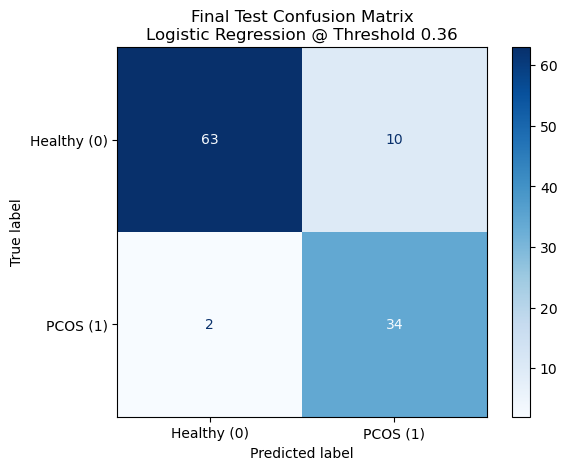

In [ ]:

final_threshold = 0.36

print("Evaluating final model on the holdout test set...")
y_test_probs = best_lr.predict_proba(X_test)[:, 1]

y_test_pred = (y_test_probs >= final_threshold).astype(int)

test_recall = recall_score(Y_test, y_test_pred, zero_division=0)
test_precision = precision_score(Y_test, y_test_pred, zero_division=0)
test_f2 = fbeta_score(Y_test, y_test_pred, beta=2, zero_division=0)
test_accuracy = accuracy_score(Y_test, y_test_pred)

print("\n--- FINAL TEST SET PERFORMANCE ---")
print(f"Test Recall:    {test_recall:.4f} (Goal: ~0.90)")
print(f"Test Precision: {test_precision:.4f} (Goal: ~0.71)")
print(f"Test F2 Score:  {test_f2:.4f}")
print(f"Test Accuracy:  {test_accuracy:.4f}\n")

# 5. Display the full classification report
print("Classification Report:")
print(classification_report(Y_test, y_test_pred, zero_division=0))

# 6. Visualize the Confusion Matrix for a clear clinical breakdown
ConfusionMatrixDisplay.from_predictions(
    Y_test, 
    y_test_pred, 
    cmap='Blues', 
    display_labels=['Healthy (0)', 'PCOS (1)']
)
plt.title(f'Final Test Confusion Matrix\nLogistic Regression @ Threshold {final_threshold}')
plt.show()

# Training on complete data and packaging

In [ ]:
import joblib
from pathlib import Path
from sklearn.base import clone

MODEL_DIR = Path('artifacts')
MODEL_DIR.mkdir(exist_ok=True)

application_model = clone(best_lr)

print("Training production model on the full dataset (X, Y)...")
application_model.fit(X, Y)

model_bundle = {
    'model': application_model,
    'threshold': 0.36, 
    'features': final_features,
    'target': 'PCOS (Y/N)',
    'model_name': 'Logistic Regression (Saga, Elasticnet, C=0.1)',
    'test_metrics': {
        'Recall': 0.9444,
        'Precision': 0.7727,
        'F2': 0.9043,
        'Accuracy': 0.8899
    },
    'clinical_note': 'Educational PCOS risk screening model. Not a medical diagnosis tool.'
}

model_path = MODEL_DIR / 'pcos_clinical_model_v1.joblib'
joblib.dump(model_bundle, model_path)

print(f"\nModel successfully packaged and saved to: {model_path}")
print("Deployment Instructions:")
print("1. Load the model using joblib.load()")
print("2. Pass new patient data through predict_proba()")
print("3. Flag patient if probability >= bundle['threshold']")

Training production model on the full dataset (X, Y)...

Model successfully packaged and saved to: artifacts\pcos_clinical_model_v1.joblib
Deployment Instructions:
1. Load the model using joblib.load()
2. Pass new patient data through predict_proba()
3. Flag patient if probability >= bundle['threshold']
